In [2]:
import tensorflow as tf 
from tensorflow import keras 
import tensorflow_addons as tfa
import tensorflow_hub as hub 
from sklearn.metrics import mean_absolute_error 
import numpy as np 
import datetime
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Activation, Dense, Flatten, Conv2D, MaxPooling2D, AveragePooling2D, BatchNormalization, PReLU
import os
import warnings

# Ignore irrelevant warning messages for cleaner output
warnings.filterwarnings('ignore')

c:\Users\ALFIAN\anaconda3\envs\env_insightface\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\ALFIAN\anaconda3\envs\env_insightface\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.11.0 and strictly below 2.14.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.15.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do no

In [3]:
train_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//train_ds') \
    .cache().shuffle(buffer_size=1000, seed=42).prefetch(buffer_size=tf.data.AUTOTUNE)

valid_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//val_ds') \
    .cache().shuffle(buffer_size=1000, seed=42).prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds, valid_ds

NotFoundError: NewRandomAccessFile failed to Create/Open: C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//train_ds\dataset_spec.pb : The system cannot find the path specified.
; No such process

Load Arcface


In [4]:
# Import fungsi untuk membuat model ArcFace
from models import create_arcface_model

# Load dengan weights (default)
arcface_112 = create_arcface_model(load_weights=True)

# Membekukan layer ArcFace
arcface_112.trainable = False

# Menampilkan ringkasan model ArcFace
arcface_112.summary()



⚠ Warning: Could not load weights from C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//arcface_weights.h5
  Error: [Errno 2] Unable to synchronously open file (unable to open file: name = 'C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//arcface_weights.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
  Model will be initialized with random weights.
Model: "ArcFace"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 112, 112, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 114, 114, 3)          0         ['input_1[0][0]']             
                           

✓ Successfully loaded weights from C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//arcface_weights.h5


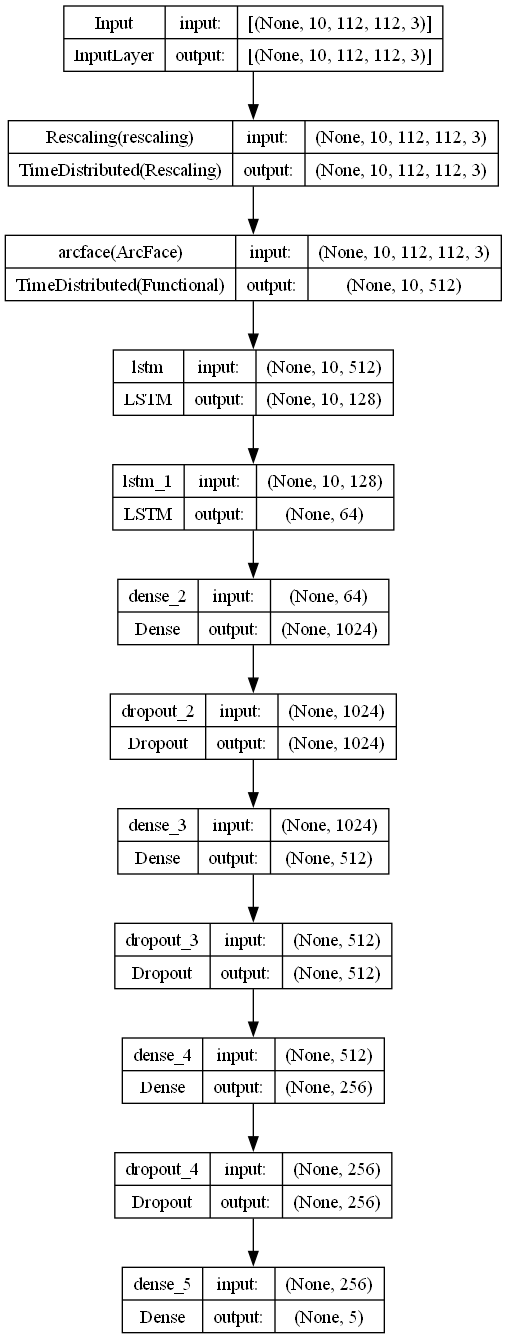

In [5]:
from models import create_arcface_model
from tensorflow.keras import regularizers

# Load ArcFace model
arcface_112 = create_arcface_model()
arcface_112.trainable = False

# Build model dengan TimeDistributed untuk sequence input
inputs = keras.layers.Input(shape=(10, 112, 112, 3), name='Input')

# Preprocessing
x = keras.layers.TimeDistributed(keras.layers.Rescaling(scale=1./255.0), name='Rescaling')(inputs)

# ArcFace feature extractor (tetap dibekukan)
x = keras.layers.TimeDistributed(arcface_112, name='arcface')(x)

# LSTM layers
x = keras.layers.LSTM(units=128, return_sequences=True)(x)
x = keras.layers.LSTM(units=64)(x)

# Dense + Dropout + Regularization
x = keras.layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = keras.layers.Dropout(0.3)(x)

x = keras.layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = keras.layers.Dropout(0.3)(x)

x = keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = keras.layers.Dropout(0.5)(x)

# Output
x = keras.layers.Dense(5, activation='sigmoid')(x)

# Build model
model = keras.models.Model(inputs=inputs, outputs=x)
keras.utils.plot_model(model, show_shapes=True)

In [ ]:
# Timestemp Define File Checkpoint
t = datetime.datetime.now().strftime("%m%d_%H%M%S")

# INPUT OPTIMIZER DISINI

#3 optimizer = keras.optimizers.Adam(learning_rate=0.001)
optimizer = keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)
## optimizer = tfa.optimizers.RectifiedAdam(learning_rate=0.001)
## optimizer = keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)


# Call Backs
early_stopping = keras.callbacks.EarlyStopping(patience=10, verbose=1)
check_point    = keras.callbacks.ModelCheckpoint(filepath='./weights/faces/'+str(t)+'/face.t5',
                            monitor='val_mae',
                            mode='min',
                            save_best_only=True,
                            save_weights_only=True,
                            verbose=1)

# Compile Model
model.compile(loss='mse', optimizer=optimizer, metrics=['mae'])

# Print konfirmasi
print(f"[INFO] Model dikompilasi dengan Adam optimizer. Checkpoint disimpan di '{checkpoint_dir}face.t5'")

In [7]:
history = model.fit(train_ds, validation_data=valid_ds, batch_size=8, epochs=100, callbacks=[early_stopping, check_point])

Epoch 1/100
8/8 [==============================] - ETA: 0s - loss: 11.6696 - mae: 0.4990
Epoch 1: val_mae improved from inf to 0.49857, saving model to ./weights/faces/1019_230215\face.t5
8/8 [==============================] - 30s 3s/step - loss: 11.6696 - mae: 0.4990 - val_loss: 11.6600 - val_mae: 0.4986
Epoch 2/100
8/8 [==============================] - ETA: 0s - loss: 11.6487 - mae: 0.4978
Epoch 2: val_mae improved from 0.49857 to 0.49695, saving model to ./weights/faces/1019_230215\face.t5
8/8 [==============================] - 23s 3s/step - loss: 11.6487 - mae: 0.4978 - val_loss: 11.6320 - val_mae: 0.4970
Epoch 3/100
8/8 [==============================] - ETA: 0s - loss: 11.6169 - mae: 0.4963
Epoch 3: val_mae improved from 0.49695 to 0.49493, saving model to ./weights/faces/1019_230215\face.t5
8/8 [==============================] - 22s 3s/step - loss: 11.6169 - mae: 0.4963 - val_loss: 11.5979 - val_mae: 0.4949
Epoch 4/100
8/8 [==============================] - ETA: 0s - loss: 11.5

### Load weights

In [9]:
model.load_weights('./weights/faces/1019_230215/face.t5')

## Evaluation

### Training data

In [10]:
train_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//train_ds') 
loss, mae = model.evaluate(train_ds)
(1-mae)*100

8/8 [==============================] - 16s 2s/step - loss: 8.3734 - mae: 0.2144


78.55701148509979

In [11]:
y_true = np.concatenate([y for x,y in train_ds])
y_pred = model.predict(train_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

8/8 [==============================] - 17s 2s/step


(array([79.40547 , 79.526924, 77.05473 , 77.31852 , 79.47941 ],
       dtype=float32),
 78.55701148509979)

### Validation data

In [12]:
valid_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//val_ds') 
loss, mae = model.evaluate(valid_ds)
(1-mae)*100

3/3 [==============================] - 5s 2s/step - loss: 8.3733 - mae: 0.2142


78.58271300792694

In [13]:
y_true = np.concatenate([y for x,y in valid_ds])
y_pred = model.predict(valid_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

3/3 [==============================] - 5s 2s/step


(array([79.436424, 79.56785 , 77.066956, 77.33209 , 79.510254],
       dtype=float32),
 78.58271598815918)

### Test data

In [14]:
test_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//test_ds')
loss, mae = model.evaluate(test_ds)
(1-mae)*100

3/3 [==============================] - 5s 2s/step - loss: 8.3738 - mae: 0.2153


78.47428023815155

In [15]:
y_true = np.concatenate([y for x,y in test_ds])
y_pred = model.predict(test_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

3/3 [==============================] - 5s 2s/step


(array([79.3351  , 79.457115, 76.954384, 77.234856, 79.38995 ],
       dtype=float32),
 78.47428023815155)

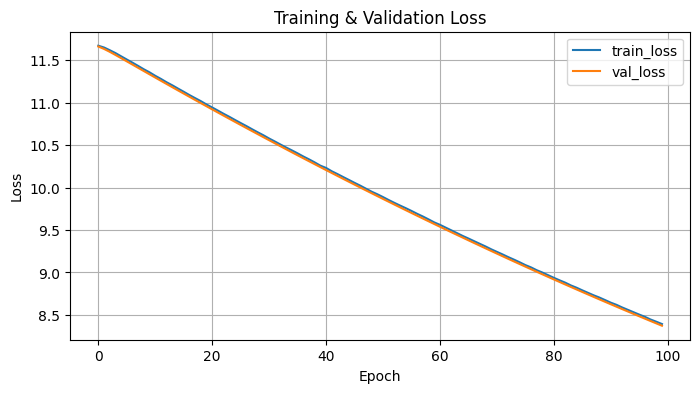

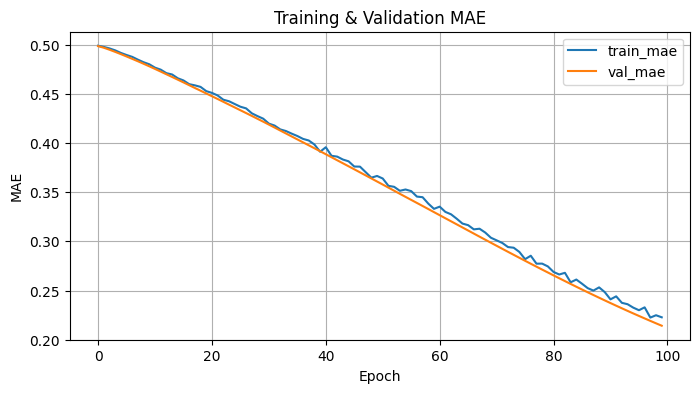

In [16]:
import matplotlib.pyplot as plt

# 1) Plot Loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'],    label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 2) Plot MAE (atau metric lain yang kamu pakai)
plt.figure(figsize=(8,4))
plt.plot(history.history['mae'],     label='train_mae')
plt.plot(history.history['val_mae'], label='val_mae')
plt.title('Training & Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()